# CelebA Attribute Analysis
Analyse every CelebA attribute: how many **smile** vs **non-smile** images fall under each attribute class.
Used to design OOD certification subsets (50 smile + 50 non-smile per attribute).

In [1]:
import sys, os, random
sys.path.insert(0, os.path.abspath(".."))

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── paths ────────────────────────────────────────────────────────────────────
CELEBA_ROOT = Path("/BS/databases08/CelebA")
ATTR_FILE   = CELEBA_ROOT / "Anno" / "list_attr_celeba.txt"

# Split settings — must match src/dataloaders/celeba_smile.py _split_by_ratio()
# Uses Python random.Random(seed).shuffle — NOT sklearn
TRAIN_RATIO = 0.8
VAL_RATIO   = 0.1   # test = remaining 10%
SPLIT_SEED  = 73

print("Attribute file:", ATTR_FILE.exists())

Attribute file: True


## Load full attribute table
Parse `list_attr_celeba.txt` into a DataFrame with all 40 attributes + Smiling label.

In [2]:
def load_celeba_attrs(attr_path: Path) -> pd.DataFrame:
    lines = [l.strip() for l in attr_path.read_text().splitlines() if l.strip()]
    attr_names = lines[1].split()
    rows = []
    for line in lines[2:]:
        parts = line.split()
        filename = parts[0]
        vals = [int(v) for v in parts[1:]]  # -1 or 1
        rows.append([filename] + vals)
    df = pd.DataFrame(rows, columns=["filename"] + attr_names)
    # convert -1/1 → 0/1
    for col in attr_names:
        df[col] = (df[col] == 1).astype(int)
    return df

def assign_splits(df: pd.DataFrame, train_ratio: float, val_ratio: float, seed: int) -> pd.DataFrame:
    """Exact replica of src/dataloaders/celeba_smile.py _split_by_ratio().
    Uses Python random.Random(seed).shuffle — same RNG as the dataloader."""
    filenames = df["filename"].tolist()
    rng = random.Random(seed)
    shuffled = list(filenames)
    rng.shuffle(shuffled)

    n_total = len(shuffled)
    n_train = int(n_total * train_ratio)
    n_val   = int(n_total * val_ratio)

    split_map = {}
    for f in shuffled[:n_train]:
        split_map[f] = "train"
    for f in shuffled[n_train : n_train + n_val]:
        split_map[f] = "val"
    for f in shuffled[n_train + n_val :]:
        split_map[f] = "test"

    df = df.copy()
    df["split"] = df["filename"].map(split_map)
    return df

df = load_celeba_attrs(ATTR_FILE)
df = assign_splits(df, TRAIN_RATIO, VAL_RATIO, SPLIT_SEED)

ATTR_COLS = [c for c in df.columns if c not in ("filename", "split")]
print(f"Total images : {len(df):,}")
print(f"Attributes   : {len(ATTR_COLS)}")
for s in ("train", "val", "test"):
    print(f"  {s}: {(df.split==s).sum():,}")
df.head(3)

Total images : 202,599
Attributes   : 40
  train: 162,079
  val: 20,259
  test: 20,261


,filename,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young,split
0,000001.jpg,0,1,1,0,0,0,0,0,0,...,1,1,0,1,0,1,0,0,1,train
1,000002.jpg,0,0,0,1,0,0,0,1,0,...,1,0,0,0,0,0,0,0,1,train
2,000003.jpg,0,0,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,1,train


## Per-attribute smile counts (full dataset + test split)
For each of the 40 attributes, count how many images with `attribute=1` are **smile** vs **non-smile**.

In [3]:
def attr_smile_table(df_sub: pd.DataFrame, label: str = "") -> pd.DataFrame:
    """For every attribute, count smile / non-smile among images where attr=1."""
    records = []
    total = len(df_sub)
    if total == 0:
        raise ValueError(f"Empty DataFrame passed to attr_smile_table (label={label!r}). "
                         "Check that assign_splits() ran correctly.")
    for attr in ATTR_COLS:
        sub = df_sub[df_sub[attr] == 1]
        n_attr   = len(sub)
        n_smile  = int(sub["Smiling"].sum())
        n_nsmile = n_attr - n_smile
        feasible = (n_smile >= 50) and (n_nsmile >= 50)
        records.append({
            "Attribute": attr,
            "Attr=1 count": n_attr,
            "% of split": round(100 * n_attr / total, 1),
            "Smile (attr=1)": n_smile,
            "Non-smile (attr=1)": n_nsmile,
            "Smile %": round(100 * n_smile / n_attr, 1) if n_attr else 0,
            "OOD feasible (≥50 each)": "✅" if feasible else "❌",
        })
    return pd.DataFrame(records).sort_values("Attr=1 count", ascending=False).reset_index(drop=True)

# Full dataset
tbl_full = attr_smile_table(df, "full")
print("=== FULL DATASET ===")
display(tbl_full)

# Test split only  ← use string label now (assign_splits returns "train"/"val"/"test")
df_test = df[df["split"] == "test"].copy()
tbl_test = attr_smile_table(df_test, "test")
print(f"\n=== TEST SPLIT ({len(df_test):,} images) ===")
display(tbl_test)

=== FULL DATASET ===


,Attribute,Attr=1 count,% of split,Smile (attr=1),Non-smile (attr=1),Smile %,OOD feasible (≥50 each)
0,No_Beard,169158,83.5,85786,83372,50.7,✅
1,Young,156734,77.4,74152,82582,47.3,✅
2,Attractive,103833,51.3,57537,46296,55.4,✅
3,Mouth_Slightly_Open,97942,48.3,74351,23591,75.9,✅
4,Smiling,97669,48.2,97669,0,100.0,❌
5,Wearing_Lipstick,95715,47.2,55322,40393,57.8,✅
6,High_Cheekbones,92189,45.5,78899,13290,85.6,✅
7,Male,84434,41.7,33798,50636,40.0,✅
8,Heavy_Makeup,78390,38.7,46499,31891,59.3,✅
9,Wavy_Hair,64744,32.0,34753,29991,53.7,✅



=== TEST SPLIT (20,261 images) ===


,Attribute,Attr=1 count,% of split,Smile (attr=1),Non-smile (attr=1),Smile %,OOD feasible (≥50 each)
0,No_Beard,16943,83.6,8632,8311,50.9,✅
1,Young,15558,76.8,7391,8167,47.5,✅
2,Attractive,10265,50.7,5783,4482,56.3,✅
3,Smiling,9793,48.3,9793,0,100.0,❌
4,Mouth_Slightly_Open,9783,48.3,7427,2356,75.9,✅
5,Wearing_Lipstick,9515,47.0,5588,3927,58.7,✅
6,High_Cheekbones,9275,45.8,7961,1314,85.8,✅
7,Male,8452,41.7,3370,5082,39.9,✅
8,Heavy_Makeup,7808,38.5,4697,3111,60.2,✅
9,Wavy_Hair,6450,31.8,3528,2922,54.7,✅


## Bar chart — smile vs non-smile per attribute (test split)
Only attributes where `attr=1` has ≥50 smile AND ≥50 non-smile are highlighted (OOD feasible).

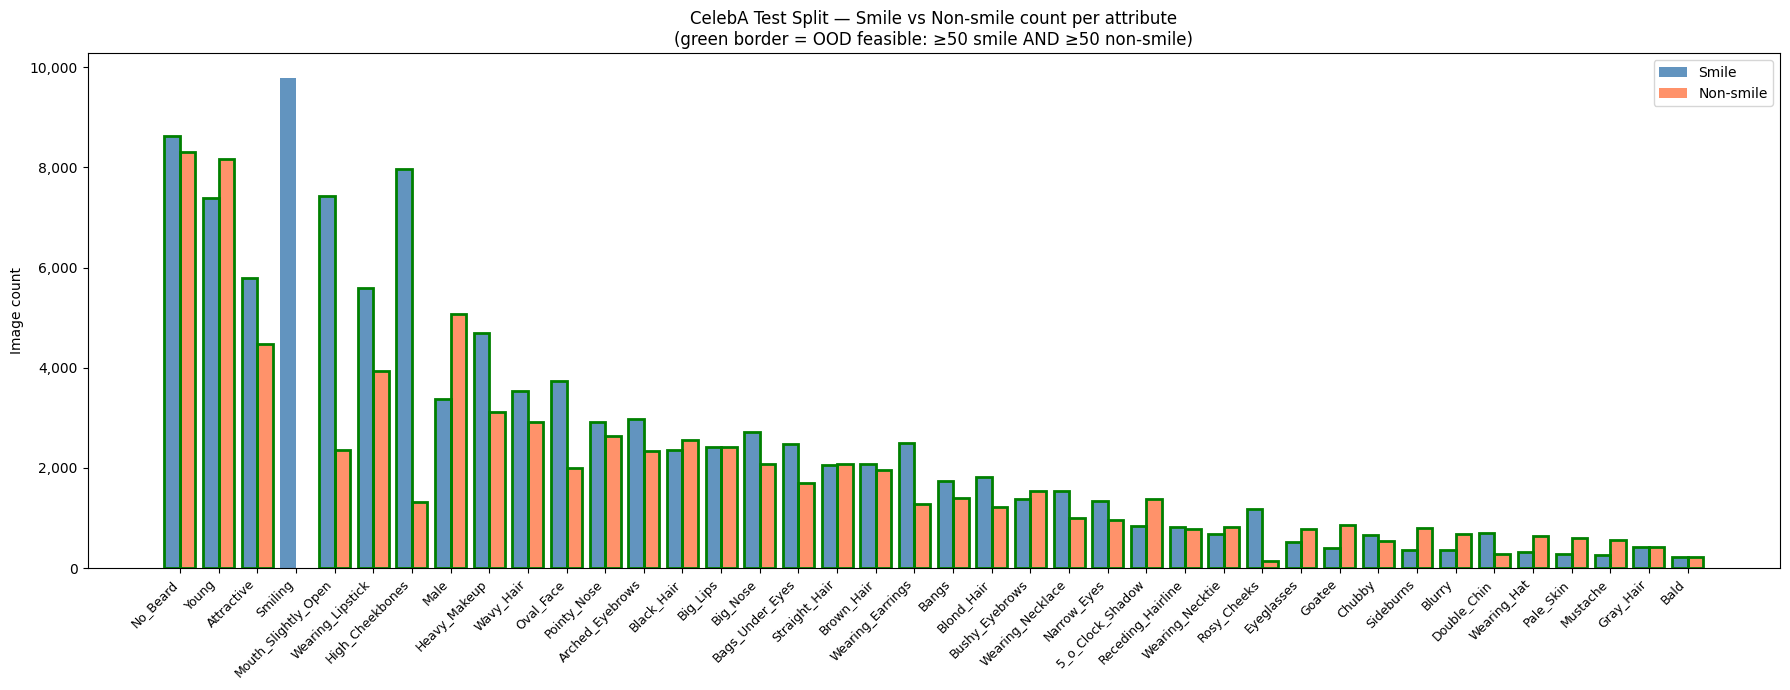

Saved: celeba_attr_smile_counts.png


In [4]:
fig, ax = plt.subplots(figsize=(18, 7))

attrs  = tbl_test["Attribute"].tolist()
smiles = tbl_test["Smile (attr=1)"].tolist()
nsmiles= tbl_test["Non-smile (attr=1)"].tolist()
feasible = tbl_test["OOD feasible (≥50 each)"].tolist()

x = np.arange(len(attrs))
w = 0.4
bars1 = ax.bar(x - w/2, smiles,  w, label="Smile",     color="steelblue",  alpha=0.85)
bars2 = ax.bar(x + w/2, nsmiles, w, label="Non-smile", color="coral", alpha=0.85)

# green border for feasible attributes
for i, f in enumerate(feasible):
    if f == "✅":
        ax.bar(x[i] - w/2, smiles[i],  w, color="none", edgecolor="green", linewidth=2)
        ax.bar(x[i] + w/2, nsmiles[i], w, color="none", edgecolor="green", linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(attrs, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Image count")
ax.set_title("CelebA Test Split — Smile vs Non-smile count per attribute\n(green border = OOD feasible: ≥50 smile AND ≥50 non-smile)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
plt.tight_layout()
plt.savefig("celeba_attr_smile_counts.png", dpi=150)
plt.show()
print("Saved: celeba_attr_smile_counts.png")

## OOD-feasible attributes summary
These attributes have ≥50 smile AND ≥50 non-smile in the **test split** → suitable for OOD certification.

In [5]:
feasible_attrs = tbl_test[tbl_test["OOD feasible (≥50 each)"] == "✅"].copy()
print(f"OOD-feasible attributes in test split: {len(feasible_attrs)}\n")
display(feasible_attrs[["Attribute","Attr=1 count","% of split","Smile (attr=1)","Non-smile (attr=1)","Smile %"]])

# Print as YAML list for easy copy-paste into certify config
print("\nFor certify config (ood_attributes):")
for attr in feasible_attrs["Attribute"].tolist():
    print(f"  - {attr}")

OOD-feasible attributes in test split: 39



,Attribute,Attr=1 count,% of split,Smile (attr=1),Non-smile (attr=1),Smile %
0,No_Beard,16943,83.6,8632,8311,50.9
1,Young,15558,76.8,7391,8167,47.5
2,Attractive,10265,50.7,5783,4482,56.3
4,Mouth_Slightly_Open,9783,48.3,7427,2356,75.9
5,Wearing_Lipstick,9515,47.0,5588,3927,58.7
6,High_Cheekbones,9275,45.8,7961,1314,85.8
7,Male,8452,41.7,3370,5082,39.9
8,Heavy_Makeup,7808,38.5,4697,3111,60.2
9,Wavy_Hair,6450,31.8,3528,2922,54.7
10,Oval_Face,5732,28.3,3733,1999,65.1



For certify config (ood_attributes):
  - No_Beard
  - Young
  - Attractive
  - Mouth_Slightly_Open
  - Wearing_Lipstick
  - High_Cheekbones
  - Male
  - Heavy_Makeup
  - Wavy_Hair
  - Oval_Face
  - Pointy_Nose
  - Arched_Eyebrows
  - Black_Hair
  - Big_Lips
  - Big_Nose
  - Bags_Under_Eyes
  - Straight_Hair
  - Brown_Hair
  - Wearing_Earrings
  - Bangs
  - Blond_Hair
  - Bushy_Eyebrows
  - Wearing_Necklace
  - Narrow_Eyes
  - 5_o_Clock_Shadow
  - Receding_Hairline
  - Wearing_Necktie
  - Rosy_Cheeks
  - Eyeglasses
  - Goatee
  - Chubby
  - Sideburns
  - Blurry
  - Double_Chin
  - Wearing_Hat
  - Pale_Skin
  - Mustache
  - Gray_Hair
  - Bald


## Simulate OOD test subset (50 smile + 50 non-smile) per attribute
Show exactly which filenames would be sampled for each feasible attribute.

In [ ]:
SEED = 73
N_PER_CLASS = 50   # 50 smile + 50 non-smile = 100 total

rng = np.random.default_rng(SEED)

def sample_ood_subset(df_test: pd.DataFrame, attr: str, n: int = 50, seed: int = 73) -> pd.DataFrame:
    """Sample n smile + n non-smile from test images where attr=1."""
    sub = df_test[df_test[attr] == 1]
    smile    = sub[sub["Smiling"] == 1].sample(n=n, random_state=seed)
    nonsmile = sub[sub["Smiling"] == 0].sample(n=n, random_state=seed)
    return pd.concat([smile, nonsmile]).reset_index(drop=True)

summary_rows = []
for attr in feasible_attrs["Attribute"].tolist():
    subset = sample_ood_subset(df_test, attr, N_PER_CLASS, SEED)
    summary_rows.append({
        "Attribute": attr,
        "Total sampled": len(subset),
        "Smile": int(subset["Smiling"].sum()),
        "Non-smile": N_PER_CLASS,
        "Sample filenames (first 3)": ", ".join(subset["filename"].iloc[:3].tolist()),
    })

summary_df = pd.DataFrame(summary_rows)
print(f"OOD subset: {N_PER_CLASS} smile + {N_PER_CLASS} non-smile per attribute")
display(summary_df)

## Smile rate heatmap across attribute pairs
Shows smile prevalence when two attributes co-occur — useful to understand distribution shifts.

In [ ]:
# Pick top-N most common OOD-feasible attrs for the heatmap
TOP_N = 15
top_attrs = feasible_attrs.nlargest(TOP_N, "Attr=1 count")["Attribute"].tolist()

smile_rates = np.zeros((TOP_N, TOP_N))
for i, a in enumerate(top_attrs):
    for j, b in enumerate(top_attrs):
        sub = df_test[(df_test[a] == 1) & (df_test[b] == 1)]
        smile_rates[i, j] = sub["Smiling"].mean() if len(sub) > 0 else np.nan

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    smile_rates, annot=True, fmt=".2f", cmap="RdYlGn",
    xticklabels=top_attrs, yticklabels=top_attrs,
    vmin=0, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title(f"Smile rate when attr_i=1 AND attr_j=1 (test split, top {TOP_N} attrs)")
plt.tight_layout()
plt.savefig("celeba_smile_rate_heatmap.png", dpi=150)
plt.show()

## Visual samples: Mouth_Slightly_Open — smile vs non-smile
Show 5 smile + 5 non-smile images from the full dataset where `Mouth_Slightly_Open=1`.

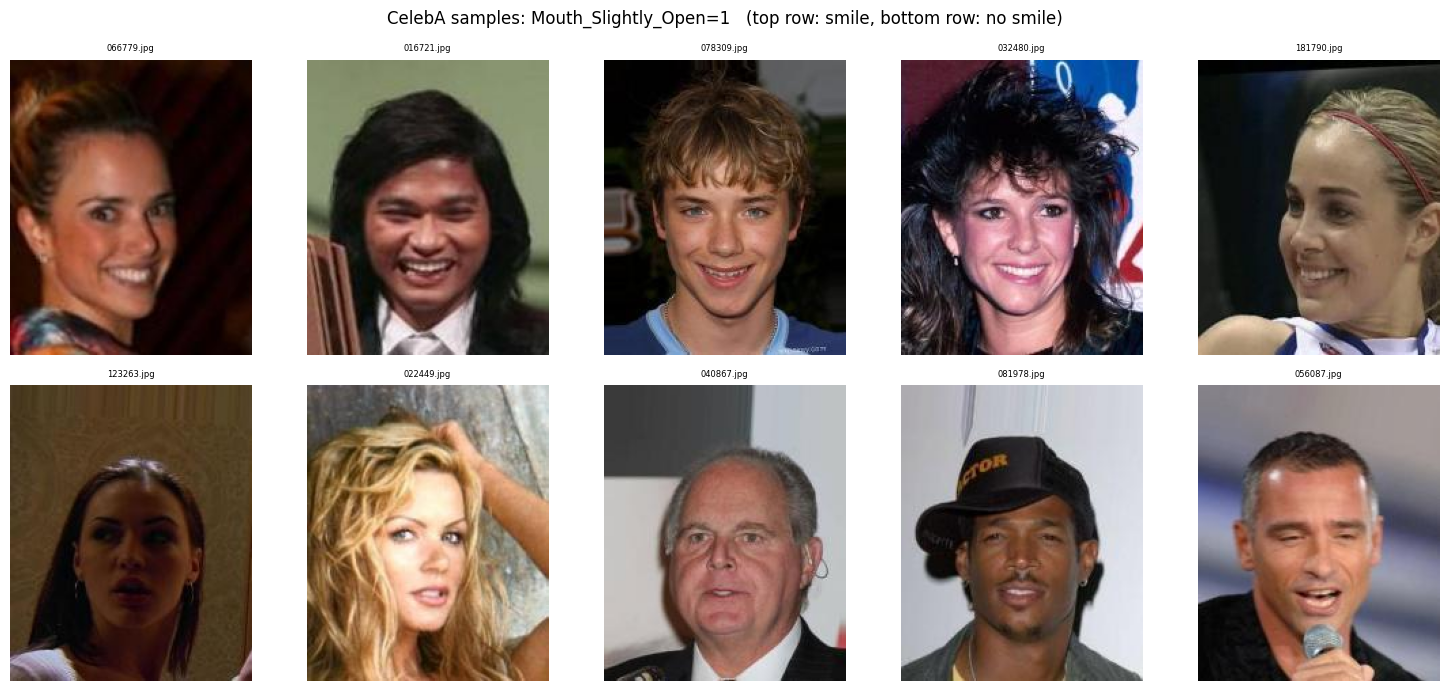

Saved: celeba_mouth_slightly_open_samples.png


In [6]:
from PIL import Image

ATTR        = "Mouth_Slightly_Open"
N_SHOW      = 5
SAMPLE_SEED = 73
IMAGE_DIR   = CELEBA_ROOT / "img_align_celeba"

# Full dataset rows where the attribute is present
sub = df[df[ATTR] == 1]
smile_samples    = sub[sub["Smiling"] == 1].sample(N_SHOW, random_state=SAMPLE_SEED)
nonsmile_samples = sub[sub["Smiling"] == 0].sample(N_SHOW, random_state=SAMPLE_SEED)

fig, axes = plt.subplots(2, N_SHOW, figsize=(3 * N_SHOW, 7))

for row_idx, (row_df, row_label) in enumerate([
    (smile_samples,    f"Smile=1  |  {ATTR}=1"),
    (nonsmile_samples, f"Smile=0  |  {ATTR}=1"),
]):
    for col_idx, (_, row) in enumerate(row_df.iterrows()):
        ax = axes[row_idx, col_idx]
        img_path = IMAGE_DIR / row["filename"]
        try:
            img = Image.open(img_path).convert("RGB")
            ax.imshow(img)
        except FileNotFoundError:
            ax.text(0.5, 0.5, "not found", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(row["filename"], fontsize=6)
        ax.axis("off")
    axes[row_idx, 0].set_ylabel(row_label, fontsize=10, fontweight="bold", labelpad=8)

fig.suptitle(f"CelebA samples: {ATTR}=1   (top row: smile, bottom row: no smile)", fontsize=12)
plt.tight_layout()
plt.savefig(f"celeba_{ATTR.lower()}_samples.png", dpi=150)
plt.show()
print(f"Saved: celeba_{ATTR.lower()}_samples.png")

## Attribute smile imbalance ranking (full dataset)
For each attribute, compute the smile imbalance ratio among `attr=1` images.
High imbalance → the attribute strongly co-occurs with smile (or non-smile) → interesting OOD shift.

=== FULL DATASET — sorted by smile imbalance (most skewed first) ===


,Attribute,Attr=1 count,Smile (attr=1),Non-smile (attr=1),Smile %,Imbalance ratio,Dominant class,OOD feasible (≥50)
0,Smiling,97669,97669,0,100.0,inf,smile,❌
1,Rosy_Cheeks,13315,11963,1352,89.8,8.85,smile,✅
2,High_Cheekbones,92189,78899,13290,85.6,5.94,smile,✅
3,Mouth_Slightly_Open,97942,74351,23591,75.9,3.15,smile,✅
4,Double_Chin,9459,6698,2761,70.8,2.43,smile,✅
5,Pale_Skin,8701,2745,5956,31.5,2.17,non-smile,✅
6,Sideburns,11449,3636,7813,31.8,2.15,non-smile,✅
7,Mustache,8417,2699,5718,32.1,2.12,non-smile,✅
8,Goatee,12716,4284,8432,33.7,1.97,non-smile,✅
9,Wearing_Hat,9818,3342,6476,34.0,1.94,non-smile,✅


/BS/dniazi_thesis/work/miniforge3_new/envs/smoothing/lib/python3.11/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),
/BS/dniazi_thesis/work/miniforge3_new/envs/smoothing/lib/python3.11/site-packages/matplotlib/transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


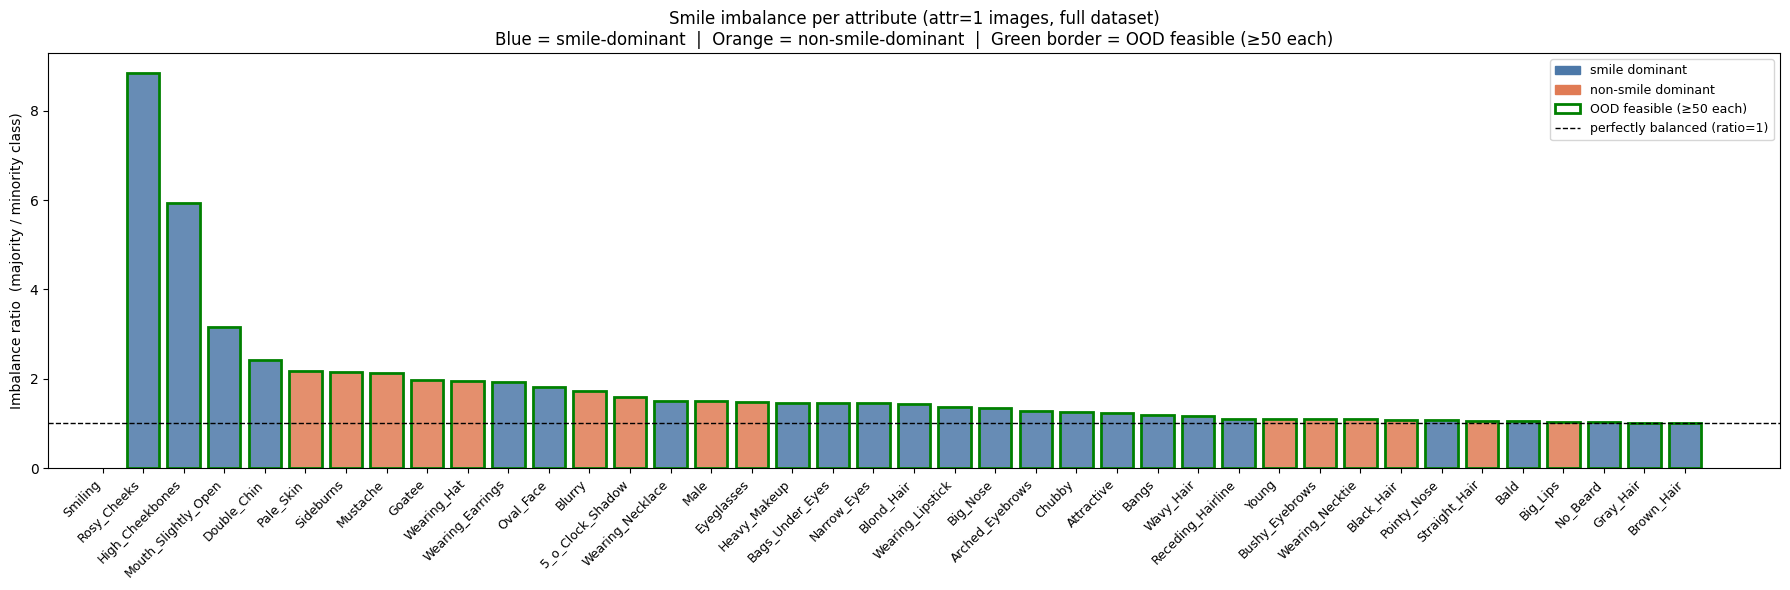

Saved: celeba_attr_imbalance_ranking.png

OOD-feasible attributes ranked by imbalance (39 total):
(most skewed first — certifying these will show the largest distribution shift)

  Rosy_Cheeks                     ratio=   8.8  smile=11963  non-smile= 1352  (89.8% smile)  dominant=smile
  High_Cheekbones                 ratio=   5.9  smile=78899  non-smile=13290  (85.6% smile)  dominant=smile
  Mouth_Slightly_Open             ratio=   3.1  smile=74351  non-smile=23591  (75.9% smile)  dominant=smile
  Double_Chin                     ratio=   2.4  smile= 6698  non-smile= 2761  (70.8% smile)  dominant=smile
  Pale_Skin                       ratio=   2.2  smile= 2745  non-smile= 5956  (31.5% smile)  dominant=non-smile
  Sideburns                       ratio=   2.1  smile= 3636  non-smile= 7813  (31.8% smile)  dominant=non-smile
  Mustache                        ratio=   2.1  smile= 2699  non-smile= 5718  (32.1% smile)  dominant=non-smile
  Goatee                          ratio=   2.0  smile

In [7]:
def imbalance_table(df_sub: pd.DataFrame, label: str = "") -> pd.DataFrame:
    """
    For every attribute, compute smile imbalance among attr=1 images.
    imbalance_ratio = max(smile, non-smile) / min(smile, non-smile)
    Higher = more skewed. Also flags OOD feasibility (>=50 each class).
    """
    records = []
    total = len(df_sub)
    for attr in ATTR_COLS:
        sub = df_sub[df_sub[attr] == 1]
        n_attr   = len(sub)
        if n_attr == 0:
            continue
        n_smile  = int(sub["Smiling"].sum())
        n_nsmile = n_attr - n_smile
        smile_pct = round(100 * n_smile / n_attr, 1)
        minority  = min(n_smile, n_nsmile)
        majority  = max(n_smile, n_nsmile)
        ratio     = round(majority / minority, 2) if minority > 0 else float("inf")
        dominant  = "smile" if n_smile > n_nsmile else "non-smile"
        feasible  = (n_smile >= 50) and (n_nsmile >= 50)
        records.append({
            "Attribute"           : attr,
            "Attr=1 count"        : n_attr,
            "Smile (attr=1)"      : n_smile,
            "Non-smile (attr=1)"  : n_nsmile,
            "Smile %"             : smile_pct,
            "Imbalance ratio"     : ratio,   # majority / minority
            "Dominant class"      : dominant,
            "OOD feasible (≥50)"  : "✅" if feasible else "❌",
        })
    return (
        pd.DataFrame(records)
        .sort_values("Imbalance ratio", ascending=False)
        .reset_index(drop=True)
    )

# ── full dataset ──────────────────────────────────────────────────────────────
imb_full = imbalance_table(df, "full")
print("=== FULL DATASET — sorted by smile imbalance (most skewed first) ===")
display(imb_full)

# ── bar chart ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 6))
colors = ["#e07b54" if d == "non-smile" else "#4c78a8" for d in imb_full["Dominant class"]]
bars = ax.bar(imb_full["Attribute"], imb_full["Imbalance ratio"], color=colors, alpha=0.85, edgecolor="white")

# green border for OOD feasible
for i, (f, r) in enumerate(zip(imb_full["OOD feasible (≥50)"], imb_full["Imbalance ratio"])):
    if f == "✅":
        ax.bar(imb_full["Attribute"].iloc[i], r, color="none", edgecolor="green", linewidth=2)

ax.axhline(1.0, color="black", linewidth=1, linestyle="--", label="perfectly balanced (ratio=1)")
ax.set_xticks(range(len(imb_full)))
ax.set_xticklabels(imb_full["Attribute"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Imbalance ratio  (majority / minority class)")
ax.set_title(
    "Smile imbalance per attribute (attr=1 images, full dataset)\n"
    "Blue = smile-dominant  |  Orange = non-smile-dominant  |  Green border = OOD feasible (≥50 each)"
)
# legend patches
import matplotlib.patches as mpatches
ax.legend(handles=[
    mpatches.Patch(color="#4c78a8", label="smile dominant"),
    mpatches.Patch(color="#e07b54", label="non-smile dominant"),
    mpatches.Patch(facecolor="none", edgecolor="green", linewidth=2, label="OOD feasible (≥50 each)"),
    ax.lines[0],
], fontsize=9)
plt.tight_layout()
plt.savefig("celeba_attr_imbalance_ranking.png", dpi=150)
plt.show()
print("Saved: celeba_attr_imbalance_ranking.png")

# ── print suggested certification order ──────────────────────────────────────
feasible_imb = imb_full[imb_full["OOD feasible (≥50)"] == "✅"]
print(f"\nOOD-feasible attributes ranked by imbalance ({len(feasible_imb)} total):")
print("(most skewed first — certifying these will show the largest distribution shift)\n")
for _, row in feasible_imb.iterrows():
    print(f"  {row['Attribute']:30s}  ratio={row['Imbalance ratio']:6.1f}  "
          f"smile={row['Smile (attr=1)']:5d}  non-smile={row['Non-smile (attr=1)']:5d}  "
          f"({row['Smile %']}% smile)  dominant={row['Dominant class']}")